# San Francisco International Airport(SFO) Air Passenger Traffic Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import StrMethodFormatter

# supressing pandas warning for this notebook for better clarity
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Importing

In [2]:
# for the dataset refer to: https://catalog.data.gov/dataset/air-traffic-passenger-statistics 

air_traffic_df = pd.read_csv('./Air_Traffic_Passenger_Statistics.csv')
display(air_traffic_df.head())

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,2025/08/21 08:21:35 AM,2025/08/22 03:03:24 PM
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,2025/08/21 08:21:35 AM,2025/08/22 03:03:24 PM
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,2025/08/21 08:21:35 AM,2025/08/22 03:03:24 PM
3,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,1324,2025/08/21 08:21:35 AM,2025/08/22 03:03:24 PM
4,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,1198,2025/08/21 08:21:35 AM,2025/08/22 03:03:24 PM


## Data Cleaning

In [3]:
# remove columns data_as_of and data_loaded_at since they are not related to the analysis
air_traffic_df.drop(columns=['data_as_of', 'data_loaded_at'], inplace=True)

# remove rows that have all NaN values
air_traffic_df.dropna(how="all", inplace=True)

In [4]:
# creating two new columns Activity Year and Activity Month
air_traffic_df['Activity Year'] = air_traffic_df['Activity Period Start Date'].apply(lambda x: x.split('/')[0])
air_traffic_df['Activity Year'] = air_traffic_df['Activity Year'].astype('int')
month_dict = {
    '01': 'January',
    '02': 'February',
    '03': 'March',
    '04': 'April',
    '05': 'May',
    '06': 'June',
    '07': 'July',
    '08': 'August',
    '09': 'September',
    '10': 'October',
    '11': 'November',
    '12': 'December'
}
air_traffic_df['Activity Month'] = air_traffic_df['Activity Period Start Date'].apply(lambda x: month_dict[x.split('/')[1]])
display(air_traffic_df.head())

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Activity Year,Activity Month
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,1999,July
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,1999,July
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,1999,July
3,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,1324,1999,July
4,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,1198,1999,July


## Data Exploration

### Analysis-1 : Summer Passenger Traffic Trends at SFO (2015–2024, Deplaned Passengers)

#### Data Cleaning & Augmentation

In [5]:
# filtering data for years 2015–2024
air_traffic_decade_df = air_traffic_df[(air_traffic_df['Activity Year'] >= 2015) & (air_traffic_df['Activity Year'] <= 2024)]

In [6]:
# filtering data for summer months (June, July, August)
filtered_df = air_traffic_decade_df[air_traffic_decade_df['Activity Month'].isin(('June', 'July', 'August'))]

In [7]:
# filtering data for deplaned passengers
filtered_df = filtered_df[filtered_df['Activity Type Code'] == 'Deplaned']

#### Visualization & Insights

In [8]:
# summing passenger counts by year and month
summer_traffic_df = filtered_df.groupby(['Activity Year', 'Activity Month'])['Passenger Count'].sum()
display(summer_traffic_df.head())

Activity Year  Activity Month
2015           August            2438908
               July              2448567
               June              2247789
2016           August            2593874
               July              2650944
Name: Passenger Count, dtype: int64

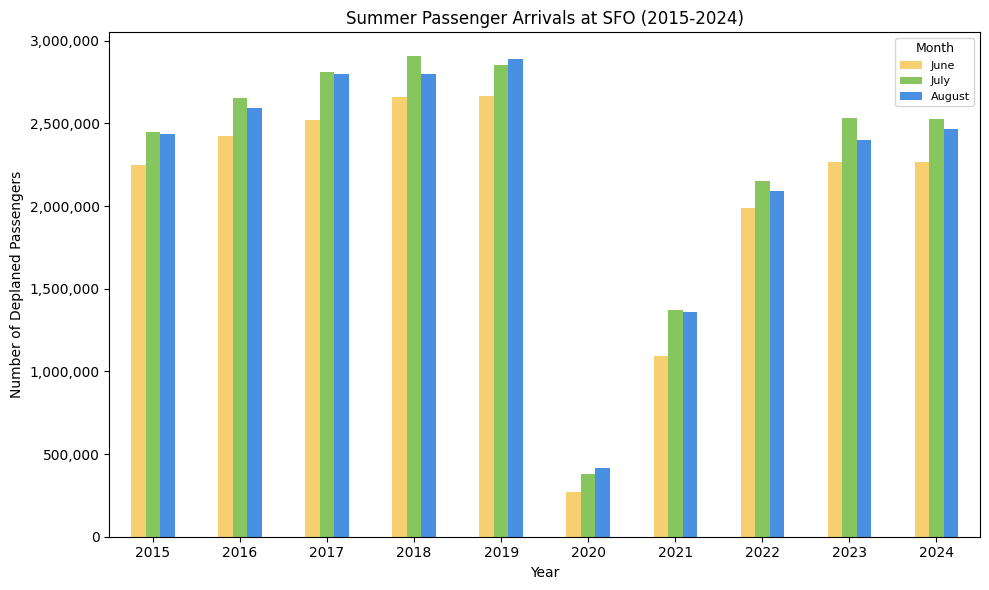

In [9]:
month_order = ["June", "July", "August"]

# unstacking so Activity Month become columns
summer_traffic_df = summer_traffic_df.unstack("Activity Month")

summer_traffic_df = summer_traffic_df[month_order]

custom_colors = {
    "June": "#F6CF71",
    "July": "#87c55f",   
    "August": "#4a90e2"   
}
ax = summer_traffic_df.plot(kind="bar", figsize=(10, 6), color=[custom_colors[month] for month in summer_traffic_df.columns])

plt.title("Summer Passenger Arrivals at SFO (2015-2024)")
plt.xlabel("Year")
plt.ylabel("Number of Deplaned Passengers")

ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.legend(title="Month", fontsize=8, title_fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insights** : Arriving passenger traffic at SFO grew steadily from 2015 until the sharp decline in 2020 due to the COVID-19 pandemic and travel restrictions. Since then, arrivals have been recovering each year but haven’t quite reached pre-pandemic highs yet. Across most years, July shows the highest arrivals compared to June and August, consistently being the month to receive the highest number of vistors in Summer.

### Analysis-2 : Domestic vs International Passenger Traffic Trends at SFO (2015–2024, Deplaned Passengers)

#### Data Cleaning & Augmentation

In [10]:
# filtering data for deplaned passengers
geo_summary_df = air_traffic_decade_df[air_traffic_decade_df['Activity Type Code'] == 'Deplaned']

# summing passenger counts by year and geographic category (Domestic/International)
geo_summary_df = geo_summary_df.groupby(['Activity Year', 'GEO Summary'])['Passenger Count'].sum()

#### Visualization & Insights

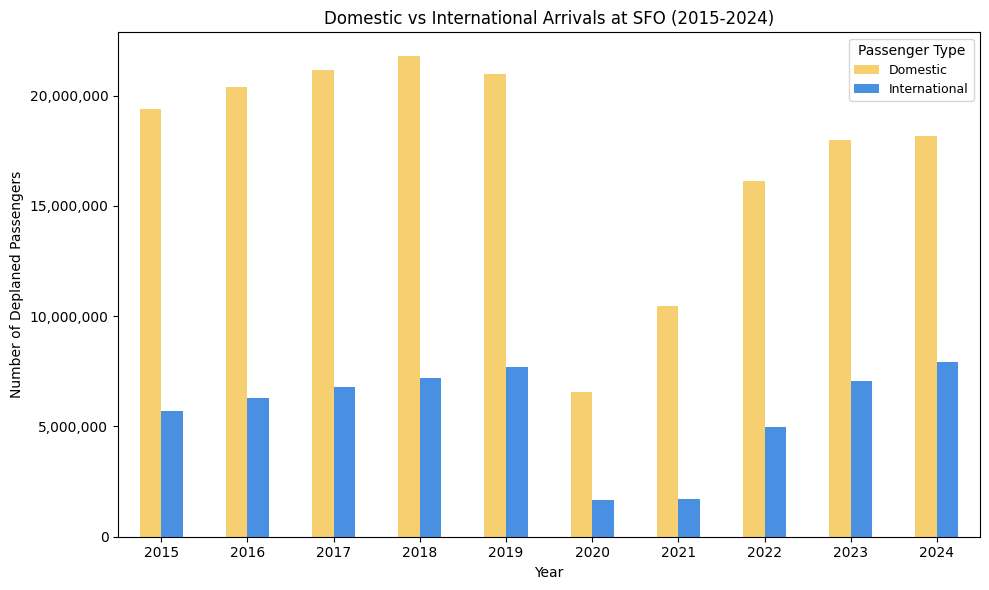

In [11]:
label_order = ["Domestic", "International"]

# unstacking so that GEO Summary (Domestic/International) become columns
geo_summary_df = geo_summary_df.unstack("GEO Summary")
geo_summary_df = geo_summary_df[label_order]

custom_colors = {
    "Domestic": "#F6CF71",
    "International": "#4a90e2",    
}

ax = geo_summary_df.plot(kind="bar", figsize=(10, 6), color=[custom_colors[month] for month in geo_summary_df.columns])

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
ax.yaxis.get_offset_text().set_visible(False)

plt.title("Domestic vs International Arrivals at SFO (2015-2024)")
plt.xlabel("Year")
plt.ylabel("Number of Deplaned Passengers")
plt.legend(title="Passenger Type", fontsize=9, title_fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insights** : SFO is driven heavily by domestic travel, even though it is a major international hub. Both domestic and international arrivals grew steadily until peaking in 2019, followed by a sharp collapse in 2020 due to COVID-19. Since then, international arrivals have gradually reached its pre-COVID highs, where as the domestic arrivals are still lagging behind.

### Analysis-3 : Top 10 Airlines chosen by International Departing Passengers at SFO (2020–2024)

#### Data Cleaning & Augmentation

In [12]:
# filtering data for years 2020 - 2024
air_traffic_5yr_df = air_traffic_df[(air_traffic_df['Activity Year'] >= 2020) & (air_traffic_df['Activity Year'] <= 2024)]

# filtering data for international flights
air_traffic_5yr_df = air_traffic_5yr_df[air_traffic_5yr_df['GEO Summary'] == 'International']

# filtering data for departures
air_traffic_5yr_df = air_traffic_5yr_df[air_traffic_5yr_df['Activity Type Code'] == 'Enplaned']


In [13]:
# summing passenger counts by Operating Airline
air_traffic_5yr_df = air_traffic_5yr_df.groupby(['Operating Airline'])['Passenger Count'].sum()
air_traffic_5yr_df = air_traffic_5yr_df.sort_values(ascending=False)

In [14]:
# filtering the data for top 10 airlines by passenger count
top_10_airlines_df = air_traffic_5yr_df.head(10)
display(top_10_airlines_df)

Operating Airline
United Airlines              8387018
Air Canada                   1453918
EVA Airways                   738483
British Airways               703701
Lufthansa German Airlines     660308
Air India Limited             636005
Aeromexico                    619406
Alaska Airlines               609659
Turkish Airlines              582873
Air France                    491023
Name: Passenger Count, dtype: int64

#### Visualization & Insights

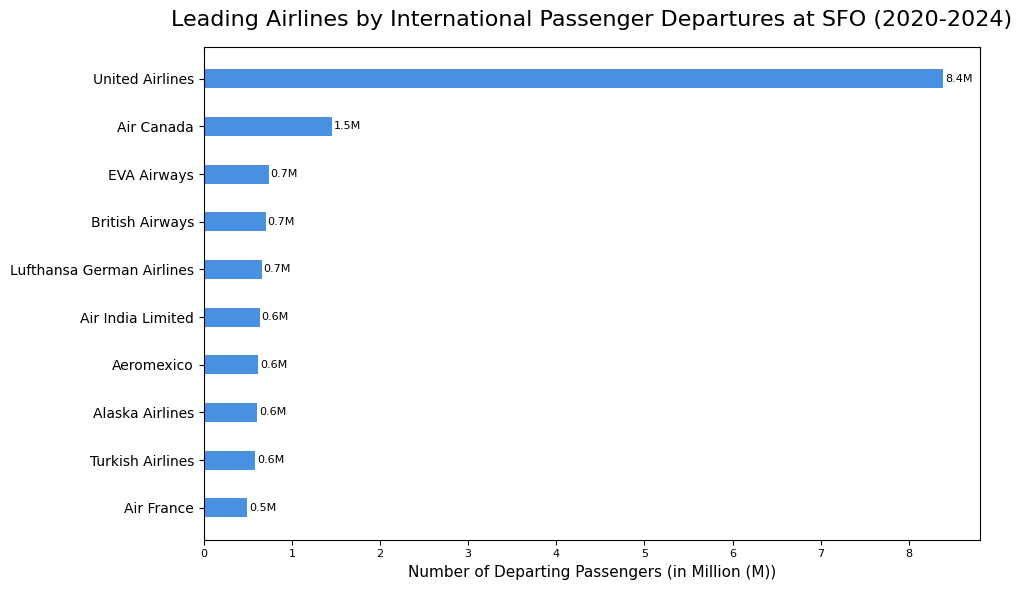

In [15]:
airlines = top_10_airlines_df.index
passenger_counts = top_10_airlines_df.values

plt.figure(figsize=(10,6))
bars = plt.barh(airlines, passenger_counts, color="#4a90e2", height=0.4)

plt.gca().invert_yaxis()
plt.title("Leading Airlines by International Passenger Departures at SFO (2020-2024)", fontsize=16, pad=15, loc="center")
plt.xlabel("Number of Departing Passengers (in Million (M))", fontsize=11)
plt.xticks(fontsize=8)
plt.yticks(fontsize=10)

ax = plt.gca()
# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.get_offset_text().set_visible(False)

for bar in bars:
    plt.text(bar.get_width() + 20000, bar.get_y() + bar.get_height()/2, f"{bar.get_width()/1000000:.1f}M", va="center", fontsize=8)

plt.tight_layout()
plt.show()

**Insights** : United Airlines overwhelmingly leads international departures from SFO, carrying more passengers than all the other top airlines combined. Air Canada stands out as a distant second, while the rest of the top 10 airlines maintain relatively similar passenger counts in the 0.5–0.75 million range.

### Analysis-4 : SFO Popularity as a Transit Hub (2015–2024)

#### Data Cleaning & Augmentation

In [16]:
# summing passenger count by Year and Activity Type Code (enplaned/depaned/thru-transit)
activity_coded_df = air_traffic_decade_df.groupby(['Activity Year', 'Activity Type Code'])['Passenger Count'].sum()

In [17]:
# unstacking so that Activity Type Code become columns
activity_coded_df = activity_coded_df.unstack('Activity Type Code')

# creating a new column with percentage of passengers in transit to total passengers
activity_coded_df['Percentage Transit'] = activity_coded_df['Thru / Transit'] * 100 / (activity_coded_df['Enplaned'] + activity_coded_df['Deplaned'] + activity_coded_df['Thru / Transit'])

In [18]:
display(activity_coded_df)

Activity Type Code,Deplaned,Enplaned,Thru / Transit,Percentage Transit
Activity Year,,,,
2015,25093661,24955019,9207,0.018393
2016,26683974,26412251,7223,0.013602
2017,27952477,27862429,8806,0.015775
2018,28964142,28736291,46440,0.080420
2019,28684054,28665071,69449,0.120952
2020,8228907,8180718,9088,0.055351
2021,12163299,12162180,9074,0.037289
2022,21088903,21047572,72583,0.171961
2023,25070834,24992086,78647,0.156850


#### Visualization & Insights

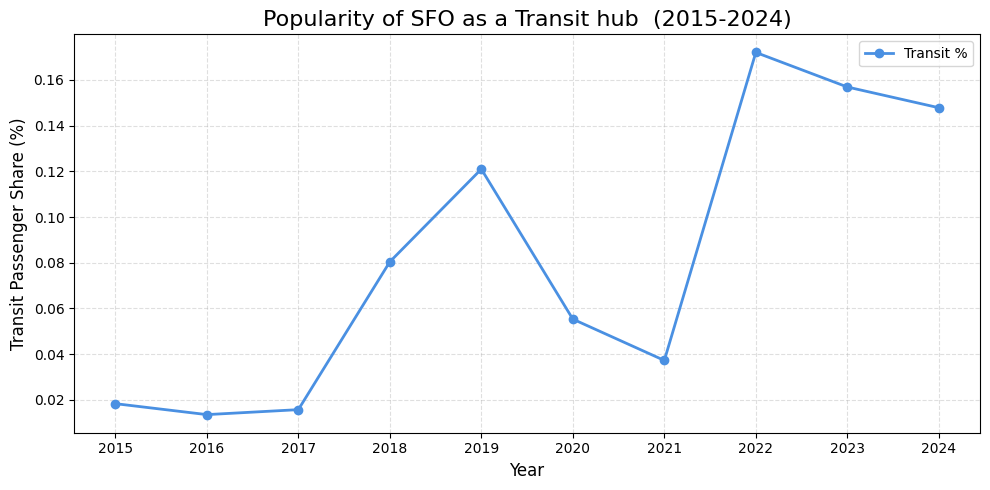

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    activity_coded_df.index, activity_coded_df['Percentage Transit'],  marker='o', linewidth=2, color='#4a90e2', label='Transit %'
)

# Titles and labels
plt.title("Popularity of SFO as a Transit hub  (2015-2024)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Transit Passenger Share (%)", fontsize=12)

# Aesthetics
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(activity_coded_df.index)
plt.legend()
plt.tight_layout()

plt.show()

**Insights** : Transit passengers make up a very small fraction of SFO’s total traffic, always under 0.2%. While the share rose sharply before the pandemic and peaked in 2022, SFO is clearly an origin & destination (O&D) airport rather than a major transit hub. SFO has seen a slight decline in the share of Transit passengers in recent years. 